In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

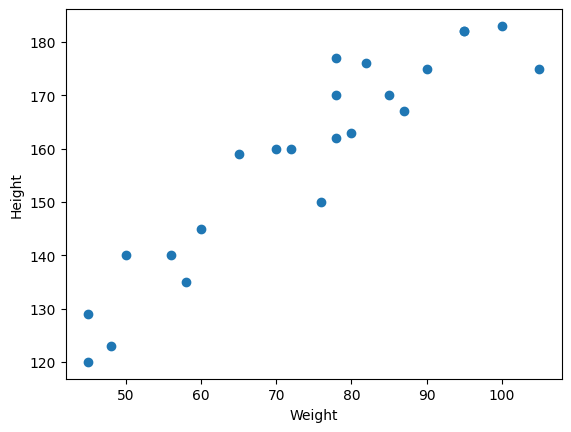

In [5]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
x_train, x_test, y_train, y_test = train_test_split(df[['Weight']], df['Height'], test_size=0.2, random_state=50)

In [7]:
x_train.head()

,Weight
8,95
3,60
19,87
17,65
7,90


In [8]:
x_test.head()

,Weight
18,76
21,56
12,105
20,45
9,78


In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
x_train_scaled[ : 5]

array([[ 1.25515331],
       [-0.87050955],
       [ 0.76928751],
       [-0.56684343],
       [ 0.95148719]])

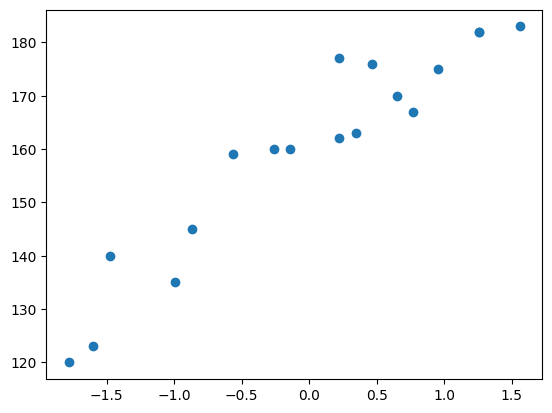

In [11]:
plt.scatter(x_train_scaled, y_train)

In [12]:
regression = LinearRegression()

In [13]:
regression.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
regression.coef_

array([18.24133653])

In [15]:
regression.intercept_

np.float64(159.94444444444446)

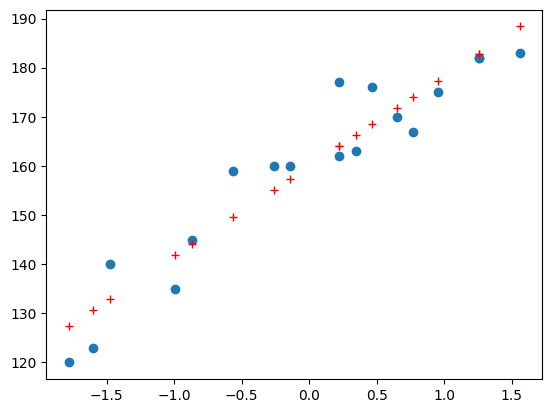

In [21]:
plt.scatter(x_train_scaled, y_train)
plt.plot(x_train_scaled, regression.predict(x_train_scaled), 'r+')

In [22]:
y_pred = regression.predict(x_test_scaled)

In [23]:
y_pred

array([161.79086976, 139.63376594, 193.91867031, 127.44735883,
       164.00658015])

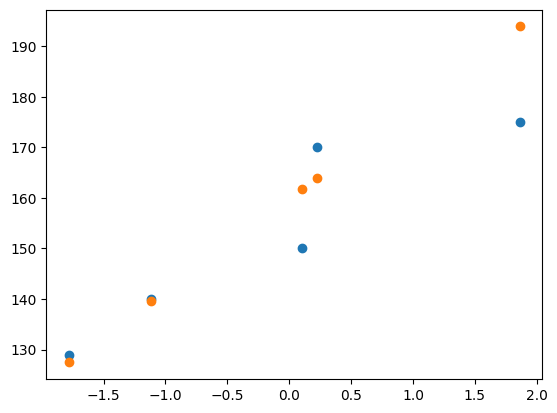

In [26]:
plt.scatter(x_test_scaled, y_test)
plt.scatter(x_test_scaled, y_pred)

In [29]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
(mse, mae, (np.sqrt(mse)))

(107.08131991713307, 7.724367030965391, np.float64(10.348010432790115))

In [30]:
r2_score(y_test, y_pred)

0.6493276135802559